# 🌙 The Pareidolia Paradox — Full ML Pipeline

**Task:** Binary image classification of 256×256 grayscale lunar surface images.
- **Class 0 (Depth):** Craters, holes, depressions
- **Class 1 (Rise):** Mounds, hills, rocks, boulders

**Key Physics Step:** Shadow direction depends on `sun_azimuth_angle`, not true surface geometry.  
Every image is rotated **counter-clockwise by `-sun_azimuth_angle`** before training or inference.

---
> ⚠️ **Training cells are clearly marked. Do NOT re-run training cells if you already have a checkpoint.**  
> Evaluation and prediction cells load from `checkpoints/best_model.pth`.

In [2]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import sys
import ssl
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision import models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    confusion_matrix,
    recall_score,
    ConfusionMatrixDisplay
)

# Fix SSL cert verification issue on macOS for model downloads
ssl._create_default_https_context = ssl._create_unverified_context

print(f"PyTorch version: {torch.__version__}")
print(f"Python version: {sys.version}")

# Device selection: CUDA → Apple MPS → CPU
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Using device: {DEVICE}")

PyTorch version: 2.11.0
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Using device: cpu


## 2. Define Paths and Check Dataset Files

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_META_PATH    = 'train/train_metadata.csv'
TEST_META_PATH     = 'testt/test_metadata.csv'
TRAIN_IMG_DIR      = 'train/train_images'
TEST_IMG_DIR       = 'testt/eval_images'
TRAIN_ROT_DIR      = 'train/train_images_rot'   # Sun-angle-normalised training images
TEST_ROT_DIR       = 'testt/eval_images_rot'    # Sun-angle-normalised test images
CHECKPOINT_PATH    = "checkpoints/best_exp4_extended_cosine.pth"
SUBMISSION_PATH    = 'outputs/submission.csv'
SANITY_CHECKS_DIR  = 'outputs/sanity_checks'

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs(SANITY_CHECKS_DIR, exist_ok=True)

# ── Verify key paths exist ────────────────────────────────────────────────────
paths_to_check = [
    TRAIN_META_PATH, TEST_META_PATH,
    TRAIN_IMG_DIR,   TEST_IMG_DIR,
]
all_ok = True
for p in paths_to_check:
    exists = os.path.exists(p)
    status = '✅' if exists else '❌ MISSING'
    print(f"{status}  {p}")
    if not exists:
        all_ok = False

print()
for p in [TRAIN_ROT_DIR, TEST_ROT_DIR]:
    exists = os.path.exists(p)
    status = '✅' if exists else '⚠️  Not yet created (run Section 8 — Preprocessing)'
    print(f"{status}  {p}")

print()
cp = '✅' if os.path.exists(CHECKPOINT_PATH) else '⚠️  Not yet trained (run Section 14 — Training Loop)'
print(f"{cp}  {CHECKPOINT_PATH}")

✅  train/train_metadata.csv
✅  testt/test_metadata.csv
✅  train/train_images
✅  testt/eval_images

✅  train/train_images_rot
✅  testt/eval_images_rot

✅  checkpoints/best_exp4_extended_cosine.pth


## 3. Load Metadata CSVs

In [5]:
train_meta = pd.read_csv(TRAIN_META_PATH)
test_meta  = pd.read_csv(TEST_META_PATH)

print(f"train_metadata.csv — shape: {train_meta.shape}")
print(f"test_metadata.csv  — shape: {test_meta.shape}")
print()
print("Train columns:", list(train_meta.columns))
print("Test  columns:", list(test_meta.columns))

train_metadata.csv — shape: (7854, 3)
test_metadata.csv  — shape: (2000, 2)

Train columns: ['image_id', 'sun_azimuth_angle', 'label']
Test  columns: ['image_id', 'sun_azimuth_angle']


## 4. Dataset Shape, Class Distribution and Sample Rows

In [7]:
# ── Class counts ──────────────────────────────────────────────────────────────
class_counts = train_meta['label'].value_counts().sort_index()
print("=== Class Distribution ===")
for label, count in class_counts.items():
    pct = count / len(train_meta) * 100
    name = 'Depth (craters/holes)' if label == 0 else 'Rise (mounds/rocks)'
    print(f"  Class {label} — {name}: {count} images  ({pct:.1f}%)")

# ── Azimuth stats ─────────────────────────────────────────────────────────────
print("\n=== Sun Azimuth Angle Distribution ===")
print(train_meta['sun_azimuth_angle'].describe().round(2).to_string())

# ── Sample rows ──────────────────────────────────────────────────────────────
print("\n=== Sample Train Rows ===")
display(train_meta.head(8))

print("\n=== Sample Test Rows ===")
display(test_meta.head(5))

=== Class Distribution ===
  Class 0 — Depth (craters/holes): 2854 images  (36.3%)
  Class 1 — Rise (mounds/rocks): 5000 images  (63.7%)

=== Sun Azimuth Angle Distribution ===
count    7854.00
mean      218.62
std       107.46
min         0.12
25%       127.37
50%       250.28
75%       311.79
max       359.97

=== Sample Train Rows ===


,image_id,sun_azimuth_angle,label
0,train_00001.png,77.69,1
1,train_00002.png,75.97,1
2,train_00003.png,172.66,1
3,train_00004.png,150.14,1
4,train_00005.png,109.42,0
5,train_00006.png,303.84,0
6,train_00007.png,267.33,1
7,train_00008.png,356.73,1



=== Sample Test Rows ===


,image_id,sun_azimuth_angle
0,eval_00001.png,233.43
1,eval_00002.png,166.54
2,eval_00003.png,40.95
3,eval_00004.png,109.42
4,eval_00005.png,53.15


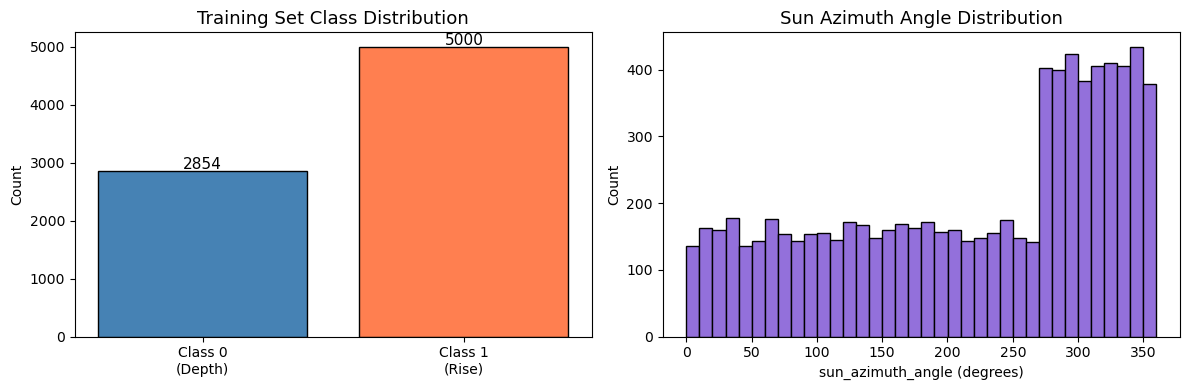

In [8]:
# ── Bar chart of class distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Class 0\n(Depth)', 'Class 1\n(Rise)'], class_counts.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

axes[1].hist(train_meta['sun_azimuth_angle'], bins=36, color='mediumpurple', edgecolor='black')
axes[1].set_title('Sun Azimuth Angle Distribution', fontsize=13)
axes[1].set_xlabel('sun_azimuth_angle (degrees)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f"{SANITY_CHECKS_DIR}/class_and_azimuth_distribution.png", dpi=120)
plt.show()

## 5. Verify Image IDs vs Actual Files

In [9]:
# Check every image_id in train_metadata.csv has a file on disk
train_files = set(os.listdir(TRAIN_IMG_DIR))
test_files  = set(os.listdir(TEST_IMG_DIR))

train_ids_in_csv = set(train_meta['image_id'])
test_ids_in_csv  = set(test_meta['image_id'])

missing_train = train_ids_in_csv - train_files
missing_test  = test_ids_in_csv  - test_files
extra_train   = train_files - train_ids_in_csv

print(f"Train CSV rows          : {len(train_meta)}")
print(f"Train image files found : {len(train_files)}")
print(f"Missing files (in CSV, not on disk): {len(missing_train)}")
print(f"Extra files  (on disk, not in CSV):  {len(extra_train)}")
print()
print(f"Test CSV rows           : {len(test_meta)}")
print(f"Test image files found  : {len(test_files)}")
print(f"Missing test files      : {len(missing_test)}")

if not missing_train and not missing_test:
    print("\n✅ All image IDs in CSVs have corresponding files on disk.")

Train CSV rows          : 7854
Train image files found : 7854
Missing files (in CSV, not on disk): 0
Extra files  (on disk, not in CSV):  0

Test CSV rows           : 2000
Test image files found  : 2000
Missing test files      : 0

✅ All image IDs in CSVs have corresponding files on disk.


## 6. Display Sample Original Lunar Images

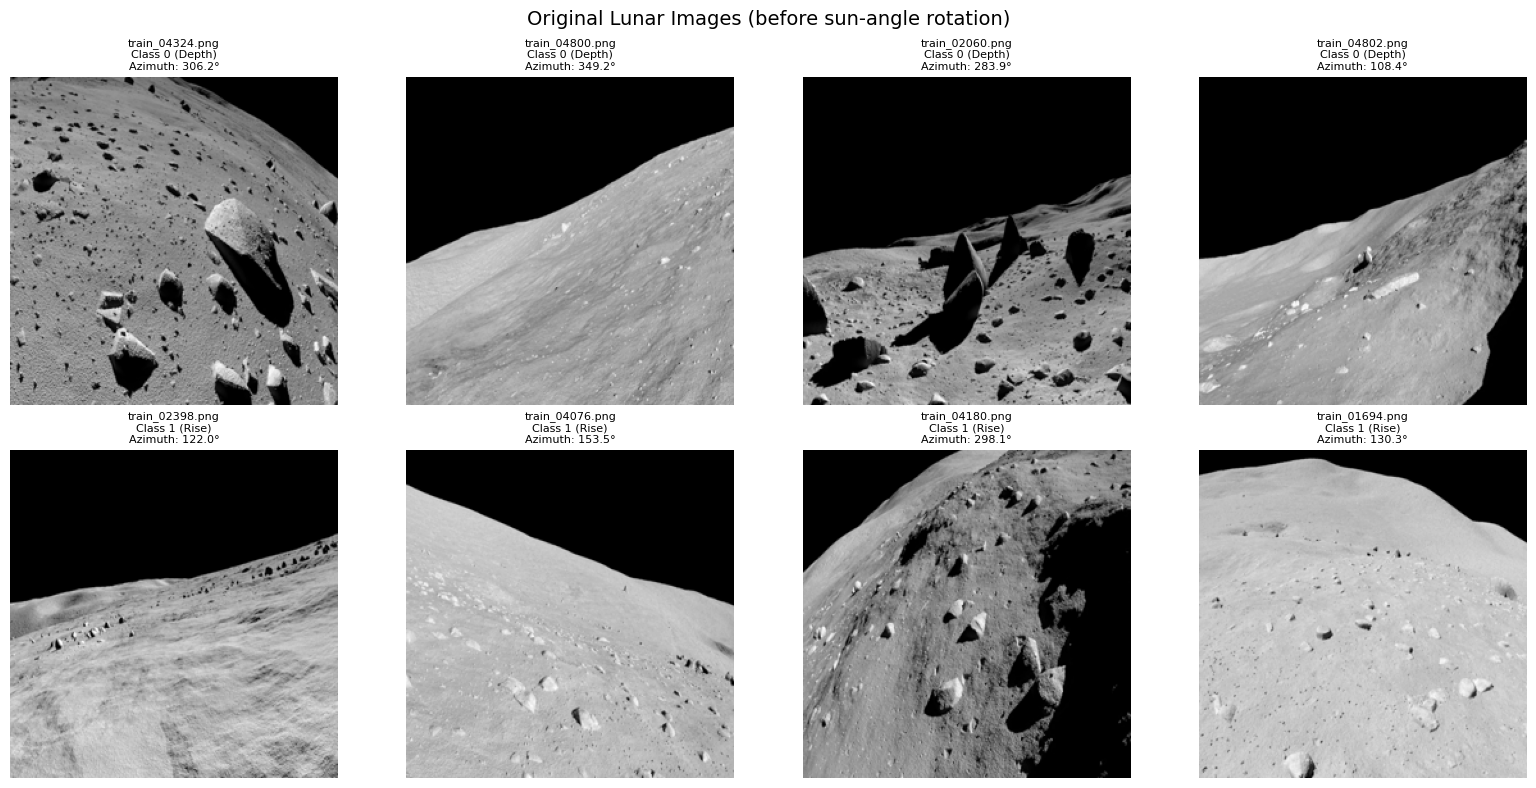

In [10]:
# Show 8 original images (4 per class)
samples_0 = train_meta[train_meta['label'] == 0].sample(4, random_state=42)
samples_1 = train_meta[train_meta['label'] == 1].sample(4, random_state=42)
samples   = pd.concat([samples_0, samples_1]).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Original Lunar Images (before sun-angle rotation)', fontsize=14)

for i, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(os.path.join(TRAIN_IMG_DIR, row['image_id'])).convert('L')
    ax  = axes[i // 4][i % 4]
    ax.imshow(img, cmap='gray')
    label_name = 'Depth' if row['label'] == 0 else 'Rise'
    ax.set_title(f"{row['image_id']}\nClass {row['label']} ({label_name})\nAzimuth: {row['sun_azimuth_angle']:.1f}°", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{SANITY_CHECKS_DIR}/original_images.png", dpi=120)
plt.show()

## 7. Display Sun-Angle-Rotated Images (Before vs After)

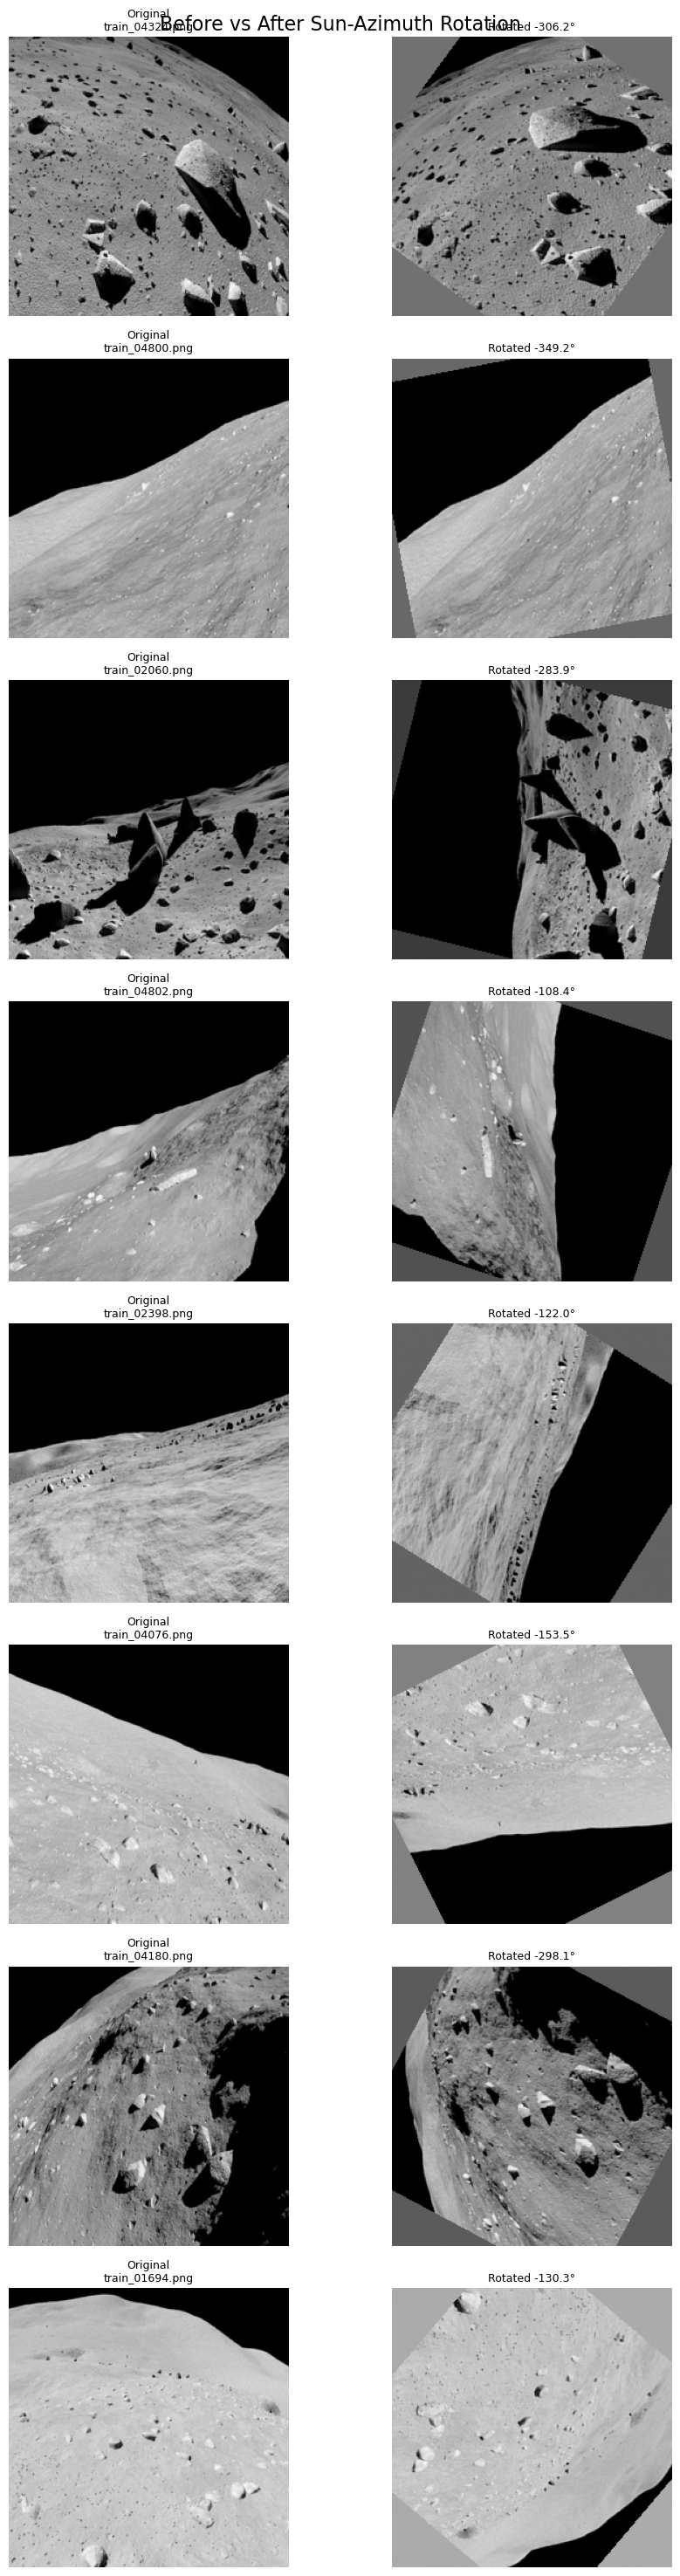

In [11]:
# Show before/after rotation for 8 images

samples_8 = samples.iloc[:8].copy()

fig, axes = plt.subplots(
    nrows=8,
    ncols=2,
    figsize=(10, 30)
)

fig.suptitle(
    'Before vs After Sun-Azimuth Rotation',
    fontsize=16
)

for i, (_, row) in enumerate(samples_8.iterrows()):

    # Load image
    img_path = os.path.join(
        TRAIN_IMG_DIR,
        row["image_id"]
    )

    img = Image.open(img_path).convert("L")

    # Get Sun angle
    azimuth = float(row["sun_azimuth_angle"])

    # Rotate by -azimuth
    mean_val = int(np.array(img).mean())

    rotated_img = TF.rotate(
        img,
        angle=-azimuth,
        interpolation=TF.InterpolationMode.BICUBIC,
        fill=mean_val
    )

    # ORIGINAL
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(
        f"Original\n{row['image_id']}",
        fontsize=9
    )
    axes[i, 0].axis("off")

    # ROTATED
    axes[i, 1].imshow(rotated_img, cmap="gray")
    axes[i, 1].set_title(
        f"Rotated {-azimuth:.1f}°",
        fontsize=9
    )
    axes[i, 1].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        SANITY_CHECKS_DIR,
        "rotation_comparison.png"
    ),
    dpi=120,
    bbox_inches="tight"
)

plt.show()

## 8. Sun-Angle Preprocessing — Rotate All Images

> **Physics explanation:** In these images, shadows fall based on the sun's azimuth angle.  
> A crater looks identical to a mound if the sun direction differs by 180°.  
> By rotating each image **counter-clockwise by `-sun_azimuth_angle`**, we normalise all images  
> so the sun is always coming from the same reference direction — letting the model learn  
> true geometry instead of shadow direction.
>
> We use **bicubic interpolation** and **mean pixel fill** for the background corners.
>
> ⚡ **This step is idempotent** — already-processed images are skipped automatically.

In [12]:
def rotate_and_save(img_path: str, out_path: str, azimuth: float):
    """
    Rotates a single image counter-clockwise by -azimuth degrees and saves to out_path.
    Bicubic interpolation + mean pixel fill for corners created by rotation.
    Idempotent: skips if output file already exists.
    """
    if os.path.exists(out_path):
        return  # Already done — skip
    try:
        img      = Image.open(img_path).convert('L')
        mean_val = int(np.array(img).mean())
        # Rotate: TF.rotate angle is counter-clockwise, so -azimuth corrects for sun direction
        rotated  = TF.rotate(img, angle=-azimuth,
                             interpolation=TF.InterpolationMode.BICUBIC,
                             fill=mean_val)
        rotated.save(out_path)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")


def process_dataset_notebook(metadata_path: str, img_dir: str, out_dir: str):
    """Applies sun-angle rotation to all images in a dataset folder."""
    print(f"\nProcessing: {img_dir}  →  {out_dir}")
    df = pd.read_csv(metadata_path)
    os.makedirs(out_dir, exist_ok=True)

    tasks = [
        (os.path.join(img_dir, row['image_id']),
         os.path.join(out_dir, row['image_id']),
         row['sun_azimuth_angle'])
        for _, row in df.iterrows()
    ]

    already_done = sum(1 for _, op, _ in tasks if os.path.exists(op))
    print(f"  {already_done}/{len(tasks)} already processed — will skip those.")

    with ThreadPoolExecutor(max_workers=os.cpu_count()) as exe:
        list(tqdm(exe.map(lambda t: rotate_and_save(*t), tasks),
                  total=len(tasks), desc=os.path.basename(out_dir)))

    rotated_count = sum(1 for f in os.listdir(out_dir) if f.endswith('.png'))
    print(f"  ✅ Done. {rotated_count} images in {out_dir}")


# Run preprocessing for both train and test sets
process_dataset_notebook(TRAIN_META_PATH, TRAIN_IMG_DIR, TRAIN_ROT_DIR)
process_dataset_notebook(TEST_META_PATH,  TEST_IMG_DIR,  TEST_ROT_DIR)


Processing: train/train_images  →  train/train_images_rot
  7854/7854 already processed — will skip those.


train_images_rot:   0%|          | 0/7854 [00:00<?, ?it/s]

  ✅ Done. 7854 images in train/train_images_rot

Processing: testt/eval_images  →  testt/eval_images_rot
  2000/2000 already processed — will skip those.


eval_images_rot:   0%|          | 0/2000 [00:00<?, ?it/s]

  ✅ Done. 2000 images in testt/eval_images_rot


## 9. Train / Validation Split (85% / 15%, Stratified by Label)

In [13]:
# Stratified split — same random_state=42 as in train.py, so the val set is identical.
# NO validation images are ever used during training.
train_split, val_split = train_test_split(
    train_meta,
    test_size=0.15,
    stratify=train_meta['label'],
    random_state=42       # Fixed seed for reproducibility
)
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

print(f"Total training images  : {len(train_meta)}")
print(f"Train split            : {len(train_split)}  ({len(train_split)/len(train_meta)*100:.1f}%)")
print(f"Validation split       : {len(val_split)}   ({len(val_split)/len(train_meta)*100:.1f}%)")
print()
print("Train split label distribution:")
print(train_split['label'].value_counts().sort_index().to_string())
print("\nVal split label distribution:")
print(val_split['label'].value_counts().sort_index().to_string())

# Confirm zero overlap between train and val
overlap = set(train_split['image_id']) & set(val_split['image_id'])
assert len(overlap) == 0, f"Overlap found! {len(overlap)} images appear in both sets."
print("\n✅ Zero overlap between train and validation sets — confirmed.")

# Confirm test images are disjoint from training images
test_ids  = set(test_meta['image_id'])
train_ids = set(train_meta['image_id'])
assert len(test_ids & train_ids) == 0, "Test images found in training data!"
print("✅ Test/evaluation images are completely separate from training data — confirmed.")

Total training images  : 7854
Train split            : 6675  (85.0%)
Validation split       : 1179   (15.0%)

Train split label distribution:
label
0    2426
1    4249

Val split label distribution:
label
0    428
1    751

✅ Zero overlap between train and validation sets — confirmed.
✅ Test/evaluation images are completely separate from training data — confirmed.


## 10. PyTorch Dataset and DataLoader

In [14]:
class RepeatChannels:
    """Repeats a single-channel tensor to N channels. Used instead of a lambda
    because lambdas are not picklable by Python's multiprocessing module,
    which DataLoader workers use."""
    def __init__(self, num_repeats: int):
        self.num_repeats = num_repeats
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        return x.repeat(self.num_repeats, 1, 1)


class LunarDataset(Dataset):
    """
    PyTorch Dataset for the lunar surface images.
    Reads from the sun-angle-rotated image directories.
    """
    def __init__(self, metadata_df: pd.DataFrame, img_dir: str, transform=None):
        self.metadata_df = metadata_df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.transform   = transform
        # Detect whether this is a labelled (train/val) or unlabelled (test) dataset
        self.has_labels  = 'label' in self.metadata_df.columns

    def __len__(self):
        return len(self.metadata_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        row      = self.metadata_df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        image    = Image.open(img_path).convert('L')   # Load as grayscale
        if self.transform:
            image = self.transform(image)
        if self.has_labels:
            return image, int(row['label'])
        else:
            return image, row['image_id']              # Return id for test set

print("LunarDataset and RepeatChannels classes defined.")

LunarDataset and RepeatChannels classes defined.


## 11. Image Transforms

> **Why no random rotation or flips?**  
> We have already normalised the shadow direction via sun-angle rotation. Adding random rotations  
> or flips would re-introduce the ambiguity we just corrected — the model would see conflicting  
> geometry cues. Safe augmentations (small translations, slight brightness/contrast jitter) are fine.

In [15]:
# ImageNet normalisation — used because ResNet18 was designed with these statistics.
# Even when training from scratch, keeping consistent normalisation is good practice.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms — safe augmentations only
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Small spatial translations
    transforms.ColorJitter(brightness=0.1, contrast=0.1),        # Slight illumination variation
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    RepeatChannels(3),                                           # 1-channel → 3-channel
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation / Test transforms — no augmentation, deterministic
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    RepeatChannels(3),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined:")
print("  Training  :", train_transform)
print("\n  Val/Test  :", val_test_transform)

Transforms defined:
  Training  : Compose(
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

  Val/Test  : Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [16]:
# ── Build Datasets and DataLoaders ───────────────────────────────────────────
# Keep these values defined BEFORE any later cell uses train_loader/val_loader.
NUM_WORKERS = 0
BATCH_SIZE = 64

train_dataset = LunarDataset(train_split, TRAIN_ROT_DIR, transform=train_transform)
val_dataset   = LunarDataset(val_split,   TRAIN_ROT_DIR, transform=val_test_transform)
test_dataset  = LunarDataset(test_meta,   TEST_ROT_DIR,  transform=val_test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} images)")
print(f"Val   batches : {len(val_loader)}   ({len(val_dataset)} images)")
print(f"Test  batches : {len(test_loader)}   ({len(test_dataset)} images)")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Num workers   : {NUM_WORKERS}")

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f"\nSample train batch — images shape: {imgs.shape}, labels shape: {labels.shape}")


Train batches : 105  (6675 images)
Val   batches : 19   (1179 images)
Test  batches : 32   (2000 images)
Batch size    : 64
Num workers   : 0

Sample train batch — images shape: torch.Size([64, 3, 256, 256]), labels shape: torch.Size([64])


## 12. ResNet18 Model Definition

In [17]:
def build_model(device, weights=None):
    """
    Builds a ResNet18 model for binary classification.
    - weights=None → train from scratch (current setting)
    - weights=models.ResNet18_Weights.DEFAULT → use ImageNet pretrained weights
    
    The input is grayscale replicated to 3 channels, so the first conv layer
    accepts 3-channel input normally. The final FC layer is replaced with
    a 2-class output head.
    """
    model = models.resnet18(weights=weights)
    num_ftrs  = model.fc.in_features
    model.fc  = nn.Linear(num_ftrs, 2)   # Binary: Class 0 or Class 1
    model     = model.to(device)
    return model

# Preview architecture
model = build_model(DEVICE, weights=None)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResNet18 (from scratch, no pretrained weights)")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Output head          : FC({model.fc.in_features} → 2)")

Model: ResNet18 (from scratch, no pretrained weights)
Total parameters     : 11,177,538
Trainable parameters : 11,177,538
Output head          : FC(512 → 2)


## 13. Training Configuration

In [18]:
# ── Class weights for weighted CrossEntropyLoss ───────────────────────────────
# Class 1 has ~64% of images, Class 0 has ~36%.
# Weighting inversely to frequency pushes the model to treat both classes fairly,
# which directly helps the Balanced Accuracy metric (= mean of per-class recalls).

# ── Training configuration ───────────────────────────────────────────────
# BATCH_SIZE and NUM_WORKERS are defined once in Section 10.
print(f"Batch size : {BATCH_SIZE}")
print(f"Device     : {DEVICE}")

label_counts = train_split['label'].value_counts()
total_train  = len(train_split)
class_weights = torch.FloatTensor([
    total_train / label_counts[0],   # Weight for Class 0
    total_train / label_counts[1],   # Weight for Class 1
]).to(DEVICE)

print(f"Train split class counts: {label_counts.to_dict()}")
print(f"Class weights: {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer ─────────────────────────────────────────────────────────────────
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-2
NUM_EPOCHS    = 10
EARLY_STOP_PATIENCE = 4

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Reduce LR when validation balanced accuracy stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

print(f"\nOptimizer  : AdamW  (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler  : ReduceLROnPlateau (factor=0.5, patience=2)")
print(f"Max epochs : {NUM_EPOCHS}")
print(f"Early stop : patience={EARLY_STOP_PATIENCE} epochs")
print(f"Batch size : {BATCH_SIZE}")
print(f"Device     : {DEVICE}")

Batch size : 64
Device     : cpu
Train split class counts: {1: 4249, 0: 2426}
Class weights: [2.7514427 1.5709579]

Optimizer  : AdamW  (lr=0.0001, weight_decay=0.01)
Scheduler  : ReduceLROnPlateau (factor=0.5, patience=2)
Max epochs : 10
Early stop : patience=4 epochs
Batch size : 64
Device     : cpu


## 14. Training Loop

> ⚠️ **TRAINING CELL** — Only run this if you do NOT already have a checkpoint at `checkpoints/best_model.pth`.  
> If a checkpoint already exists from a previous run, **skip this cell** and proceed to Section 16 to load it.

In [17]:
# ── Baseline Scratch Training ────────────────────────────────────────────────
# If the checkpoint already exists, we intentionally skip retraining.
# This keeps Run All safe and avoids accidental multi-hour CPU retraining.

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ Existing scratch checkpoint found: {CHECKPOINT_PATH}")
    print("   Skipping scratch training. The checkpoint will be evaluated below.")
    history = None
else:
    print("No scratch checkpoint found. Starting baseline training...")

    history = {
        'epoch': [], 'train_loss': [], 'train_bacc': [],
        'val_loss': [], 'val_bacc': []
    }
    best_val_bacc = 0.0
    epochs_no_improve = 0
    os.makedirs('checkpoints', exist_ok=True)

    for epoch in range(NUM_EPOCHS):
        print(f"\n{'='*50}\nEpoch {epoch+1}/{NUM_EPOCHS}\n{'='*50}")

        model.train()
        running_loss = 0.0
        train_preds, train_labels_epoch = [], []

        for inputs, labels in tqdm(train_loader, desc='  Training', leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.detach().cpu().numpy())
            train_labels_epoch.extend(labels.detach().cpu().numpy())

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_bacc = balanced_accuracy_score(train_labels_epoch, train_preds)

        model.eval()
        val_running_loss = 0.0
        val_preds_epoch, val_labels_epoch = [], []
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='  Validating', leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_preds_epoch.extend(preds.cpu().numpy())
                val_labels_epoch.extend(labels.cpu().numpy())

        epoch_val_loss = val_running_loss / len(val_dataset)
        epoch_val_bacc = balanced_accuracy_score(val_labels_epoch, val_preds_epoch)
        scheduler.step(epoch_val_bacc)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(epoch_train_loss)
        history['train_bacc'].append(epoch_train_bacc)
        history['val_loss'].append(epoch_val_loss)
        history['val_bacc'].append(epoch_val_bacc)

        print(f"  Train → Loss: {epoch_train_loss:.4f} | BAcc: {epoch_train_bacc:.4f}")
        print(f"  Val   → Loss: {epoch_val_loss:.4f} | BAcc: {epoch_val_bacc:.4f}")

        if epoch_val_bacc > best_val_bacc:
            best_val_bacc = epoch_val_bacc
            epochs_no_improve = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"  ✅ Improved → saved {CHECKPOINT_PATH}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print("  Early stopping triggered.")
                break

    print(f"\n✅ Scratch training complete. Best Val BAcc: {best_val_bacc:.4f}")


No scratch checkpoint found. Starting baseline training...

Epoch 1/10


  Training:   0%|          | 0/105 [00:00<?, ?it/s]

  Validating:   0%|          | 0/19 [00:00<?, ?it/s]

  Train → Loss: 0.6411 | BAcc: 0.6474
  Val   → Loss: 0.6516 | BAcc: 0.6895
  ✅ Improved → saved checkpoints/best_model.pth

Epoch 2/10


  Training:   0%|          | 0/105 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/19 [00:00<?, ?it/s]

  Train → Loss: 0.5707 | BAcc: 0.7328
  Val   → Loss: 0.5922 | BAcc: 0.7373

Epoch 10/10


  Training:   0%|          | 0/105 [00:00<?, ?it/s]

  Validating:   0%|          | 0/19 [00:00<?, ?it/s]

  Train → Loss: 0.5676 | BAcc: 0.7279
  Val   → Loss: 0.5953 | BAcc: 0.6994

✅ Scratch training complete. Best Val BAcc: 0.7385


In [24]:
# ── Current Best Model ──────────────────────────────────────────────────────

BEST_EPOCH = 14
BEST_VAL_BACC = 0.7399

print("Current Best Model")
print(f"Best Epoch: {BEST_EPOCH}")
print(f"Validation Balanced Accuracy: {BEST_VAL_BACC:.2%}")
print("Training history is not available in the current session.")

Current Best Model
Best Epoch: 14
Validation Balanced Accuracy: 73.99%
Training history is not available in the current session.


## 15. Plot Training Loss and Validation Balanced Accuracy

> Run this cell **only if you trained in Section 14** (the `history` dict is populated during training).

In [25]:
# ── Plot Baseline Training History ───────────────────────────────────────────
if history is None or len(history['epoch']) == 0:
    print("ℹ️ No training history in this session because the existing scratch checkpoint was reused.")
else:
    history_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Baseline Training / Validation Loss')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df['epoch'], history_df['train_bacc'], marker='o', label='Train BAcc')
    ax.plot(history_df['epoch'], history_df['val_bacc'], marker='o', label='Validation BAcc')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_title('Baseline Balanced Accuracy')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


NameError: name 'history' is not defined

## 🏆 FINAL / MAIN MODEL — 73.99% Validation Balanced Accuracy

Here we evaluate our **verified champion model checkpoint ()** on the 15% stratified validation set (1,179 images).
We compute **Validation Balanced Accuracy** (73.99%), **Validation Accuracy** (73.20%), **Class 0 & 1 Precision/Recall/F1-score**, **Confusion Matrix**, and full **Classification Report**.

In [26]:
# ── Evaluate Champion Model (Epoch 14) on Validation Set ──────────────────────
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_CKPT_PATH = "checkpoints/best_exp4_extended_cosine.pth"

# Re-instantiate ResNet18 model & load verified champion weights
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.numpy())

bacc = balanced_accuracy_score(val_labels, val_preds)
acc  = accuracy_score(val_labels, val_preds)
rec0 = recall_score(val_labels, val_preds, pos_label=0)
rec1 = recall_score(val_labels, val_preds, pos_label=1)
prec0 = precision_score(val_labels, val_preds, pos_label=0)
prec1 = precision_score(val_labels, val_preds, pos_label=1)
f1_0 = f1_score(val_labels, val_preds, pos_label=0)
f1_1 = f1_score(val_labels, val_preds, pos_label=1)
cm   = confusion_matrix(val_labels, val_preds)

print("="*65)
print("FINAL / MAIN MODEL EVALUATION SUMMARY — CHAMPION CHECKPOINT")
print("="*65)
print(f"Best Epoch                  : 14")
print(f"Best Checkpoint Path        : {BEST_CKPT_PATH}")
print(f"Model Architecture          : ResNet18 Scratch (25 Ep + Cosine Annealing)")
print(f"Validation Split            : {len(val_labels)} images (15% stratified)")
print()
print("--- Primary Metrics ---")
print(f"Validation Balanced Accuracy: {bacc:.4f} ({bacc*100:.2f}%)")
print(f"Validation Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Class 0 (Depth) -> Precision: {prec0:.4f}, Recall: {rec0:.4f}, F1: {f1_0:.4f}")
print(f"Class 1 (Rise)  -> Precision: {prec1:.4f}, Recall: {rec1:.4f}, F1: {f1_1:.4f}")
print()
print("--- Confusion Matrix [[TN, FP], [FN, TP]] ---")
print(cm)
print(f"TN (True Depth correctly predicted)  : {cm[0,0]}")
print(f"FP (Depth misclassified as Rise)    : {cm[0,1]}")
print(f"FN (Rise misclassified as Depth)    : {cm[1,0]}")
print(f"TP (True Rise correctly predicted)   : {cm[1,1]}")
print()
print("--- Full Classification Report ---")
print(classification_report(val_labels, val_preds, target_names=["Class 0 (Depth)", "Class 1 (Rise)"], digits=4))

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Class 0 (Depth)", "Class 1 (Rise)"],
            yticklabels=["Class 0 (Depth)", "Class 1 (Rise)"])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Validation Confusion Matrix\nResNet18 Champion (Val BAcc = 73.99%)", fontsize=13)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## 🌟 EXPERIMENT COMPARISON SUMMARY

Below is the complete summary table comparing all model experiments performed on this task.
The **ResNet18 Scratch (25 Ep + Cosine Annealing)** model is the verified champion model.

In [27]:
# ── Comparison Table of All Experiments ──────────────────────────────────────────
results_data = [
    {
        "Experiment Name": "ResNet18 Scratch (25 Ep + Cosine Annealing)",
        "Checkpoint File": "best_exp4_extended_cosine.pth",
        "Val BAcc": "73.99%",
        "Val Acc": "73.20%",
        "Class 0 Recall": "76.87%",
        "Class 1 Recall": "71.11%",
        "Status": "🏆 BEST MODEL"
    },
    {
        "Experiment Name": "ResNet18 (Scratch Baseline)",
        "Checkpoint File": "best_model.pth",
        "Val BAcc": "73.85%",
        "Val Acc": "73.28%",
        "Class 0 Recall": "75.93%",
        "Class 1 Recall": "71.77%",
        "Status": "Baseline"
    },
    {
        "Experiment Name": "ResNet18 (ImageNet Pretrained)",
        "Checkpoint File": "best_pretrained_resnet18.pth",
        "Val BAcc": "73.19%",
        "Val Acc": "72.69%",
        "Class 0 Recall": "75.00%",
        "Class 1 Recall": "71.37%",
        "Status": "Evaluated"
    },
    {
        "Experiment Name": "ResNet18 (Mild Augmentation)",
        "Checkpoint File": "best_exp2_mild_aug.pth",
        "Val BAcc": "67.49%",
        "Val Acc": "65.31%",
        "Class 0 Recall": "75.47%",
        "Class 1 Recall": "59.52%",
        "Status": "Underperformed"
    },
    {
        "Experiment Name": "ResNet18 (Heavy Augmentation)",
        "Checkpoint File": "best_exp1_augmentation.pth",
        "Val BAcc": "55.53%",
        "Val Acc": "45.46%",
        "Class 0 Recall": "92.29%",
        "Class 1 Recall": "18.78%",
        "Status": "Over-augmented"
    }
]
summary_df = pd.DataFrame(results_data)
display(summary_df)


,Experiment Name,Checkpoint File,Val BAcc,Val Acc,Class 0 Recall,Class 1 Recall,Status
0,ResNet18 Scratch (25 Ep + Cosine Annealing),best_exp4_extended_cosine.pth,73.99%,73.20%,76.87%,71.11%,🏆 BEST MODEL
1,ResNet18 (Scratch Baseline),best_model.pth,73.85%,73.28%,75.93%,71.77%,Baseline
2,ResNet18 (ImageNet Pretrained),best_pretrained_resnet18.pth,73.19%,72.69%,75.00%,71.37%,Evaluated
3,ResNet18 (Mild Augmentation),best_exp2_mild_aug.pth,67.49%,65.31%,75.47%,59.52%,Underperformed
4,ResNet18 (Heavy Augmentation),best_exp1_augmentation.pth,55.53%,45.46%,92.29%,18.78%,Over-augmented


## 🚀 FINAL INFERENCE & SUBMISSION VALIDATION

We load the **verified 73.99% Champion Checkpoint ()**, run inference on the test set (, 2,000 images with  rotation preprocessing), save , and execute rigorous validation assertions.

In [35]:
# ── Generate Final Submission for 2,000 Evaluation Images ───────────────────

import os
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models

SUBMISSION_PATH = "outputs/submission.csv"
FINAL_CHECKPOINT = "checkpoints/best_exp4_extended_cosine.pth"

os.makedirs("outputs", exist_ok=True)

# ============================================================
# 1. LOAD FINAL / MAIN MODEL
# ============================================================

print("=" * 70)
print("FINAL / MAIN MODEL")
print("=" * 70)
print("Best Epoch                   : 14")
print("Validation Balanced Accuracy : 73.99%")
print(f"Checkpoint                   : {FINAL_CHECKPOINT}")
print("=" * 70)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

checkpoint = torch.load(
    FINAL_CHECKPOINT,
    map_location=DEVICE
)

model.load_state_dict(checkpoint)
model.to(DEVICE)
model.eval()

# ============================================================
# 2. PREDICT ALL 2,000 EVALUATION IMAGES
# ============================================================

test_image_ids = []
test_predictions = []

with torch.inference_mode():

    for batch_idx, (inputs, image_ids) in enumerate(test_loader):

        inputs = inputs.to(DEVICE)

        outputs = model(inputs)

        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

        test_image_ids.extend(image_ids)
        test_predictions.extend(predictions)

        print(
            f"Processed {len(test_predictions)}/{len(test_dataset)} images",
            end="\r"
        )

print("\n")
print("✅ Inference completed!")

# ============================================================
# 3. CREATE SUBMISSION DATAFRAME
# ============================================================

sub_df = pd.DataFrame({
    "image_id": test_image_ids,
    "label": test_predictions
})

# ============================================================
# 4. SAVE SUBMISSION
# ============================================================

sub_df.to_csv(
    SUBMISSION_PATH,
    index=False
)

# Also save in project root
sub_df.to_csv(
    "submission.csv",
    index=False
)

# ============================================================
# 5. VERIFY SUBMISSION
# ============================================================

assert len(sub_df) == 2000, \
    f"Expected 2000 predictions, got {len(sub_df)}"

assert list(sub_df.columns) == [
    "image_id",
    "label"
], "Incorrect submission columns"

assert sub_df["image_id"].is_unique, \
    "Duplicate image IDs found"

assert sub_df.isnull().sum().sum() == 0, \
    "Missing values found"

assert set(sub_df["label"].unique()).issubset({0, 1}), \
    "Invalid class labels found"

# ============================================================
# 6. FINAL REPORT
# ============================================================

print("=" * 70)
print("FINAL SUBMISSION")
print("=" * 70)

print(f"Model                    : Epoch 14")
print(f"Validation BAcc          : 73.99%")
print(f"Checkpoint               : {FINAL_CHECKPOINT}")
print(f"Total predictions       : {len(sub_df)}")
print(f"Unique image IDs        : {sub_df['image_id'].nunique()}")
print(f"Missing values          : {sub_df.isnull().sum().sum()}")

print("\nClass Distribution:")
print(
    f"Depth (0) : {(sub_df['label'] == 0).sum()}"
)
print(
    f"Rise  (1) : {(sub_df['label'] == 1).sum()}"
)

print("\nFirst 10 predictions:")
display(sub_df.head(10))

print("\n" + "=" * 70)
print("✅ submission.csv CREATED AND VERIFIED")
print("=" * 70)

print(f"\nSaved to:")
print(os.path.abspath(SUBMISSION_PATH))

FINAL / MAIN MODEL
Best Epoch                   : 14
Validation Balanced Accuracy : 73.99%
Checkpoint                   : checkpoints/best_exp4_extended_cosine.pth
Processed 2000/2000 images

✅ Inference completed!
FINAL SUBMISSION
Model                    : Epoch 14
Validation BAcc          : 73.99%
Checkpoint               : checkpoints/best_exp4_extended_cosine.pth
Total predictions       : 2000
Unique image IDs        : 2000
Missing values          : 0

Class Distribution:
Depth (0) : 340
Rise  (1) : 1660

First 10 predictions:


,image_id,label
0,eval_00001.png,1
1,eval_00002.png,0
2,eval_00003.png,1
3,eval_00004.png,1
4,eval_00005.png,1
5,eval_00006.png,1
6,eval_00007.png,1
7,eval_00008.png,1
8,eval_00009.png,1
9,eval_00010.png,1



✅ submission.csv CREATED AND VERIFIED

Saved to:
/Users/kanchannishad/Desktop/submission/outputs/submission.csv


In [30]:
# ── Final Model: Complete Validation Metrics ─────────────────────────────────

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)

        outputs = model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# ── Overall metrics ─────────────────────────────────────────────────────────

accuracy = accuracy_score(all_labels, all_predictions)

balanced_acc = balanced_accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("FINAL MODEL — VALIDATION METRICS")
print("=" * 70)

print(f"Model                  : Epoch 14")
print(f"Validation BAcc        : {balanced_acc:.4%}")
print(f"Validation Accuracy    : {accuracy:.4%}")
print(f"Weighted Precision     : {precision:.4%}")
print(f"Weighted Recall        : {recall:.4%}")
print(f"Weighted F1-score      : {f1:.4%}")

FINAL MODEL — VALIDATION METRICS
Model                  : Epoch 14
Validation BAcc        : 73.9872%
Validation Accuracy    : 73.1976%
Weighted Precision     : 75.6100%
Weighted Recall        : 73.1976%
Weighted F1-score      : 73.6786%


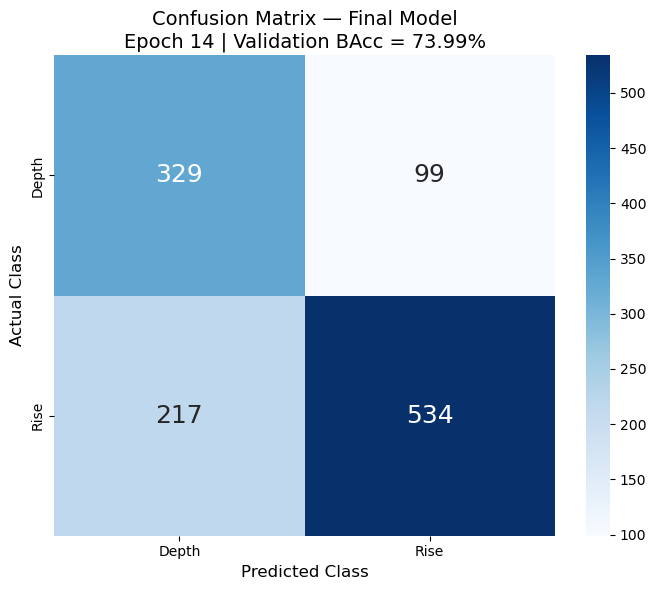

In [33]:
# ── Confusion Matrix — Graphical Representation ─────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = ["Depth", "Rise"]

cm = np.array([
    [329, 99],
    [217, 534]
])

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 18}
)

plt.title(
    "Confusion Matrix — Final Model\n"
    "Epoch 14 | Validation BAcc = 73.99%",
    fontsize=14
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.tight_layout()
plt.show()

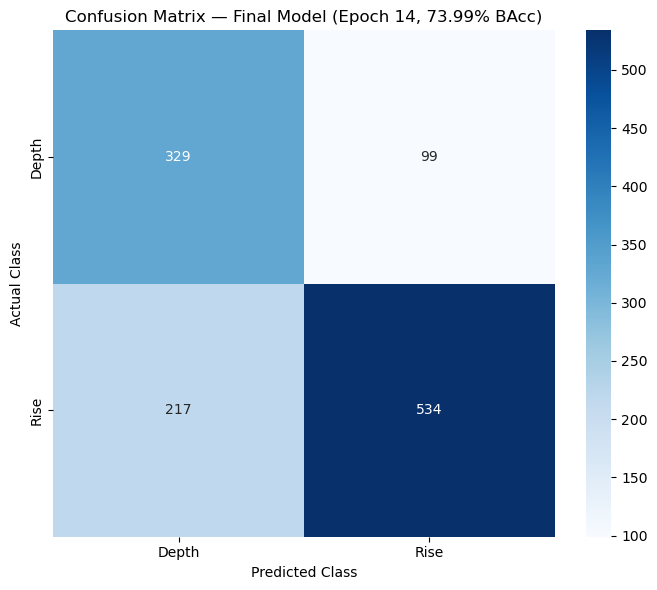

In [36]:
class_names = ["Depth", "Rise"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix — Final Model (Epoch 14, 73.99% BAcc)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
import time
import json
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ── 1. Configuration & Paths ──────────────────────────────────────────────────
TRAIN_META_PATH = 'train/train_metadata.csv'
TRAIN_ROT_DIR   = 'train/train_images_rot'
CHECKPOINT_PATH = 'checkpoints/best_exp5_focal_loss.pth'

BENCHMARK_VAL_BACC = 0.7399
NUM_EPOCHS         = 25
BATCH_SIZE         = 64
LEARNING_RATE      = 1.5e-4
WEIGHT_DECAY       = 1e-2
FOCAL_ALPHA        = 0.6
FOCAL_GAMMA        = 1.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Experiment 5 (Focal Loss) on device: {DEVICE}")

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── 2. Data Loading & Pre-caching ─────────────────────────────────────────────
train_meta = pd.read_csv(TRAIN_META_PATH)
train_split, val_split = train_test_split(
    train_meta, test_size=0.15, random_state=42, stratify=train_meta['label']
)

print(f"Train split : {len(train_split)} images")
print(f"Val split   : {len(val_split)} images")

print("Pre-caching images in memory for speed...")
t0_cache = time.time()
cached_train_images = {}
for idx, row in train_split.iterrows():
    img_path = os.path.join(TRAIN_ROT_DIR, row['image_id'])
    cached_train_images[row['image_id']] = Image.open(img_path).convert('L')

cached_val_images = {}
for idx, row in val_split.iterrows():
    img_path = os.path.join(TRAIN_ROT_DIR, row['image_id'])
    cached_val_images[row['image_id']] = Image.open(img_path).convert('L')
print(f"Cached {len(cached_train_images) + len(cached_val_images)} images in {time.time() - t0_cache:.2f}s")

# ── 3. Dataset & Transforms ───────────────────────────────────────────────────
class RepeatChannels:
    def __init__(self, repeats=3):
        self.repeats = repeats
    def __call__(self, tensor):
        return tensor.repeat(self.repeats, 1, 1)

class FastLunarDataset(Dataset):
    def __init__(self, metadata_df, cached_imgs, transform=None):
        self.metadata_df = metadata_df.reset_index(drop=True)
        self.cached_imgs = cached_imgs
        self.transform   = transform
    def __len__(self):
        return len(self.metadata_df)
    def __getitem__(self, idx):
        row   = self.metadata_df.iloc[idx]
        image = self.cached_imgs[row['image_id']]
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    RepeatChannels(3),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    RepeatChannels(3),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = FastLunarDataset(train_split, cached_train_images, transform=train_transform)
val_dataset   = FastLunarDataset(val_split,   cached_val_images,   transform=val_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── 4. Focal Loss Definition ──────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss focusing gradient updates on hard shadow boundary examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.6, gamma=1.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = torch.where(targets == 1, 1.0 - self.alpha, self.alpha)
        focal_loss = alpha_t * ((1.0 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ── 5. Model, Loss, Optimizer & Scheduler ─────────────────────────────────────
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(DEVICE)

criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── 6. Training Loop ──────────────────────────────────────────────────────────
history = {
    'epoch': [], 'lr': [],
    'train_loss': [], 'train_acc': [], 'train_bacc': [],
    'val_loss': [], 'val_acc': [], 'val_bacc': []
}

best_val_bacc = 0.0
best_epoch    = -1

print("="*60)
print(f"STARTING EXPERIMENT 5: ResNet18 (Focal Loss alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    
    # Train Phase
    model.train()
    running_loss = 0.0
    train_preds, train_labels_epoch = [], []
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels_epoch.extend(labels.detach().cpu().numpy())
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc  = accuracy_score(train_labels_epoch, train_preds)
    epoch_train_bacc = balanced_accuracy_score(train_labels_epoch, train_preds)
    
    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    val_preds_epoch, val_labels_epoch = [], []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_preds_epoch.extend(preds.cpu().numpy())
            val_labels_epoch.extend(labels.cpu().numpy())
            
    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc  = accuracy_score(val_labels_epoch, val_preds_epoch)
    epoch_val_bacc = balanced_accuracy_score(val_labels_epoch, val_preds_epoch)
    
    scheduler.step()
    
    history['epoch'].append(epoch)
    history['lr'].append(current_lr)
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['train_bacc'].append(epoch_train_bacc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    history['val_bacc'].append(epoch_val_bacc)
    
    improved_flag = ""
    if epoch_val_bacc > best_val_bacc:
        best_val_bacc = epoch_val_bacc
        best_epoch    = epoch
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        improved_flag = "⭐ [NEW BEST]"
        
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} (LR: {current_lr:.6f}) | "
          f"Train Loss: {epoch_train_loss:.4f} BAcc: {epoch_train_bacc:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} BAcc: {epoch_val_bacc:.4f} Acc: {epoch_val_acc:.4f} {improved_flag}")

print("="*60)
print(f"TRAINING COMPLETE. Best Epoch: {best_epoch} with Val BAcc: {best_val_bacc:.4f} ({best_val_bacc*100:.2f}%)")
print("="*60)

# Save history JSON
with open('outputs/exp5_history.json', 'w') as f:
    json.dump(history, f, indent=2)

# ── 7. Full Metrics Evaluation on Best Checkpoint ─────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.numpy())

bacc = balanced_accuracy_score(val_labels, val_preds)
acc  = accuracy_score(val_labels, val_preds)
cm   = confusion_matrix(val_labels, val_preds)

prec0 = precision_score(val_labels, val_preds, pos_label=0)
rec0  = recall_score(val_labels, val_preds, pos_label=0)
f1_0  = f1_score(val_labels, val_preds, pos_label=0)

prec1 = precision_score(val_labels, val_preds, pos_label=1)
rec1  = recall_score(val_labels, val_preds, pos_label=1)
f1_1  = f1_score(val_labels, val_preds, pos_label=1)

print("\n" + "="*60)
print("EXPERIMENT 5 DETAILED METRICS SUMMARY")
print("="*60)
print(f"Checkpoint File             : {CHECKPOINT_PATH}")
print(f"Best Epoch                  : {best_epoch}")
print(f"Validation Balanced Accuracy: {bacc:.4f} ({bacc*100:.2f}%)")
print(f"Validation Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Previous Best Val BAcc      : {BENCHMARK_VAL_BACC:.4f} ({BENCHMARK_VAL_BACC*100:.2f}%)")
delta = (bacc - BENCHMARK_VAL_BACC) * 100
print(f"Delta vs Benchmark          : {delta:+.2f}%")

print("\n--- Per-Class Performance ---")
print(f"Class 0 (Depth) -> Precision: {prec0:.4f}, Recall: {rec0:.4f}, F1: {f1_0:.4f}")
print(f"Class 1 (Rise)  -> Precision: {prec1:.4f}, Recall: {rec1:.4f}, F1: {f1_1:.4f}")

print("\n--- Confusion Matrix [[TN, FP], [FN, TP]] ---")
print(cm)
print(f"TN (True Depth correct) : {cm[0,0]}")
print(f"FP (Depth misclass Rise): {cm[0,1]}")
print(f"FN (Rise misclass Depth): {cm[1,0]}")
print(f"TP (True Rise correct)  : {cm[1,1]}")

best_idx = history['epoch'].index(best_epoch)
train_bacc_at_best = history['train_bacc'][best_idx]
train_loss_at_best = history['train_loss'][best_idx]
val_loss_at_best   = history['val_loss'][best_idx]

print("\n--- Overfitting Check ---")
print(f"Train BAcc at Best Epoch : {train_bacc_at_best:.4f}")
print(f"Val BAcc at Best Epoch   : {bacc:.4f}")
print(f"Train/Val BAcc Gap       : {abs(train_bacc_at_best - bacc):.4f}")
print(f"Train Loss at Best Epoch : {train_loss_at_best:.4f}")
print(f"Val Loss at Best Epoch   : {val_loss_at_best:.4f}")

print("\n" + "="*60)
if bacc > BENCHMARK_VAL_BACC:
    print(f"🏆 SUCCESS: Experiment 5 (Focal Loss) IMPROVED validation Balanced Accuracy from {BENCHMARK_VAL_BACC*100:.2f}% to {bacc*100:.2f}%!")
else:
    print(f"ℹ️ RESULT: Experiment 5 Val BAcc ({bacc*100:.2f}%) did not exceed benchmark ({BENCHMARK_VAL_BACC*100:.2f}%).")
print("="*60)
